# NUS Orbital 2026 FinSight
## Machine Learning Model to predict the risk of overspending budget
Budgets are dead when it comes to just limit the amount one will spend for a specific category. In actual fact, what will be the actual risk when it comes to overspending?

### 1. Importing Relevant Libraries

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


### 2. Reading and extracting data out for analysis

In [57]:
budget_df = pd.read_csv("../data/raw_data/budgets.csv")
transaction_df = pd.read_csv("../data/raw_data/transactions.csv")
category_df = pd.read_csv("../data/raw_data/transactionsCat.csv")

In [58]:
budget_df.head()

,budgetID,userID,catID,budgetStartDate,budgetEndDate,budgetLimit,budgetName,budgetDesc,budgetFreq
0,e5a123b9-cf57-4eab-a670-f3a65f7ab93e,550e8400-e29b-41d4-a716-446655440000,6dab2073-ff40-4704-8a15-0d3593de8c52,2026-06-01,2026-06-30,400.0,Food Budget,Monthly spending on food,monthly
1,31fa82bf-26da-4ada-ab01-4a01477b971a,550e8400-e29b-41d4-a716-446655440000,26834e16-112d-49cd-bdc2-f5c8c7c1144e,2026-06-01,2026-06-30,120.0,Transport Budget,Public transport spending,monthly
2,d5423f69-08cf-4445-9267-cf76c0e050fd,86716dc1-061e-4879-bd5b-ab4701d22dc6,e5844fa7-c620-4d55-a4b4-2b4d437950fb,2026-06-01,2026-06-30,100.0,Utilities Budget,Bills and utilities,monthly
3,13cd2288-611e-4c45-8e2e-c7750aca86a3,bbeb7d1c-4820-481a-84b6-302371fb9a50,26834e16-112d-49cd-bdc2-f5c8c7c1144e,2026-05-31,2026-06-29,100.0,Transport,🚍|,monthly
4,ca1b80e6-b308-453c-913e-f549eff8bda7,bbeb7d1c-4820-481a-84b6-302371fb9a50,6dab2073-ff40-4704-8a15-0d3593de8c52,2026-06-01,2026-06-30,200.0,Food,🍔|...,monthly


In [59]:
transaction_df.head()

,transID,userID,catID,transAmt,transDate,createdAt,updatedAt,transDesc,transPaymentMethod
0,abb0d49b-0bad-467b-900a-24d501ed7e34,550e8400-e29b-41d4-a716-446655440000,6dab2073-ff40-4704-8a15-0d3593de8c52,25.5,2026-06-10,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286,Dinner at hawker center,Cash
1,3d300f28-1510-47b2-a7ed-db8442979c92,550e8400-e29b-41d4-a716-446655440000,26834e16-112d-49cd-bdc2-f5c8c7c1144e,2.0,2026-06-09,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286,MRT fare to work,EZ-Link
2,ef96d48a-c0b8-47cd-bf62-92ef3b2f281f,550e8400-e29b-41d4-a716-446655440000,cc8cf728-fe77-4f13-b7dd-9de973ae6183,5000.0,2026-06-01,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286,Monthly salary credited,Bank Transfer
3,c057b01b-0d61-49d8-9d6e-3fe0ab9ece59,86716dc1-061e-4879-bd5b-ab4701d22dc6,6dab2073-ff40-4704-8a15-0d3593de8c52,18.9,2026-06-11,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286,Lunch at food court,Cash
4,a2ad58e2-0903-4f91-85d6-a12d8285a6d8,86716dc1-061e-4879-bd5b-ab4701d22dc6,e5844fa7-c620-4d55-a4b4-2b4d437950fb,60.0,2026-06-08,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286,Internet bill payment,Credit Card


In [60]:
category_df.head()

,catID,catName,catDesc,catType
0,6dab2073-ff40-4704-8a15-0d3593de8c52,Food & Dining,"Meals, restaurants, coffee, snacks",expense
1,26834e16-112d-49cd-bdc2-f5c8c7c1144e,Transport,"Public transport, Grab, fuel, tolls",expense
2,cc8cf728-fe77-4f13-b7dd-9de973ae6183,Salary,Monthly employment income,income
3,51efabd6-edc4-48c6-8e69-a4d2cc58ca34,Entertainment,"Movies, games, streaming services",expense
4,e5844fa7-c620-4d55-a4b4-2b4d437950fb,Utilities,"Electricity, water, internet bills",expense


In [61]:
budget_df.isnull().sum()

budgetID           0
userID             0
catID              0
budgetStartDate    0
budgetEndDate      0
budgetLimit        0
budgetName         0
budgetDesc         0
budgetFreq         0
dtype: int64

In [62]:
transaction_df.isnull().sum()

transID               0
userID                0
catID                 0
transAmt              0
transDate             0
createdAt             0
updatedAt             0
transDesc             0
transPaymentMethod    0
dtype: int64

In [63]:
category_df.isnull().sum()

catID      0
catName    0
catDesc    0
catType    0
dtype: int64

### 3. Combine Relevant Data Sources Together
To form a uniform data for data analysis and data exploration

In [64]:
trans_cat_df = transaction_df.merge(
    category_df[['catID', 'catName']],
    on='catID',
    how='left'
)

trans_cat_df = trans_cat_df.rename(columns={
    'catName': 'transCategoryName'
})

In [65]:
final_df = trans_cat_df.merge(
    budget_df[
        [
            'userID',
            'catID',
            'budgetName',
            'budgetStartDate',
            'budgetEndDate',
            'budgetLimit',
            'budgetFreq'
        ]
    ],
    on=['userID', 'catID'],
    how='left'
)

In [66]:
df = final_df[
    [
        'budgetName',
        'budgetStartDate',
        'budgetEndDate',
        'budgetLimit',
        'budgetFreq',
        'transAmt',
        'transDate',
        'transCategoryName',
        'transDesc',
        'transPaymentMethod',
        'createdAt',
        'updatedAt'
    ]
]

In [67]:
df = df.rename(columns={
    'createdAt': 'transCreatedAt',
    'updatedAt': 'transUpdatedAt'
})

In [73]:
df.shape

(71990, 12)

In [68]:
df.head()

,budgetName,budgetStartDate,budgetEndDate,budgetLimit,budgetFreq,transAmt,transDate,transCategoryName,transDesc,transPaymentMethod,transCreatedAt,transUpdatedAt
0,Food Budget,2026-06-01,2026-06-30,400.00,monthly,25.5,2026-06-10,Food & Dining,Dinner at hawker center,Cash,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286
1,Food & Dining Budget,2025-07-10,2025-08-09,320.39,monthly,25.5,2026-06-10,Food & Dining,Dinner at hawker center,Cash,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286
2,Food & Dining Budget,2025-08-10,2025-09-09,384.31,monthly,25.5,2026-06-10,Food & Dining,Dinner at hawker center,Cash,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286
3,Food & Dining Budget,2025-09-10,2025-10-09,269.79,monthly,25.5,2026-06-10,Food & Dining,Dinner at hawker center,Cash,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286
4,Food & Dining Budget,2025-10-10,2025-11-09,236.26,monthly,25.5,2026-06-10,Food & Dining,Dinner at hawker center,Cash,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286


#### Null Values Analysis

In [69]:
df.isnull().sum()

budgetName            26
budgetStartDate       26
budgetEndDate         26
budgetLimit           26
budgetFreq            26
transAmt               0
transDate              0
transCategoryName      0
transDesc              0
transPaymentMethod     0
transCreatedAt         0
transUpdatedAt         0
dtype: int64

In [70]:
null_rows = df[df.isnull().any(axis=1)]
print(null_rows)

      budgetName budgetStartDate budgetEndDate  budgetLimit budgetFreq  \
21           NaN             NaN           NaN          NaN        NaN   
40           NaN             NaN           NaN          NaN        NaN   
33373        NaN             NaN           NaN          NaN        NaN   
33374        NaN             NaN           NaN          NaN        NaN   
33375        NaN             NaN           NaN          NaN        NaN   
33376        NaN             NaN           NaN          NaN        NaN   
33377        NaN             NaN           NaN          NaN        NaN   
33378        NaN             NaN           NaN          NaN        NaN   
33379        NaN             NaN           NaN          NaN        NaN   
33380        NaN             NaN           NaN          NaN        NaN   
33381        NaN             NaN           NaN          NaN        NaN   
33382        NaN             NaN           NaN          NaN        NaN   
33383        NaN             NaN      

In [71]:
df.isnull().any(axis=1).sum()

np.int64(26)

#### Removing null values

In [74]:
df.dropna(inplace=True)

In [75]:
df.shape

(71964, 12)

In [76]:
df.isnull().any(axis=1).sum()

np.int64(0)

In [112]:
df['transDate'] = pd.to_datetime(df['transDate'])

### 4. Explorartory Data Analysis

In [83]:
df.info()

<class 'pandas.DataFrame'>
Index: 71964 entries, 0 to 71989
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   budgetName          71964 non-null  str    
 1   budgetStartDate     71964 non-null  str    
 2   budgetEndDate       71964 non-null  str    
 3   budgetLimit         71964 non-null  float64
 4   budgetFreq          71964 non-null  str    
 5   transAmt            71964 non-null  float64
 6   transDate           71964 non-null  str    
 7   transCategoryName   71964 non-null  str    
 8   transDesc           71964 non-null  str    
 9   transPaymentMethod  71964 non-null  str    
 10  transCreatedAt      71964 non-null  str    
 11  transUpdatedAt      71964 non-null  str    
dtypes: float64(2), str(10)
memory usage: 7.1 MB


In [84]:
df.describe()

,budgetLimit,transAmt
count,71964.000000,71964.000000
mean,208.414449,8.859296
std,90.885024,8.209824
min,47.590000,1.000000
25%,137.990000,4.930000
50%,183.930000,7.150000
75%,279.470000,10.090000
max,452.350000,170.000000


In [85]:
df.describe(include='str')

,budgetName,budgetStartDate,budgetEndDate,budgetFreq,transDate,transCategoryName,transDesc,transPaymentMethod,transCreatedAt,transUpdatedAt
count,71964,71964,71964,71964,71964,71964,71964,71964,71964,71964
unique,8,15,15,1,365,4,28,5,7664,7664
top,Food & Dining Budget,2025-08-10,2025-09-09,monthly,2025-07-22,Food & Dining,MRT fare to work,Credit Card,2026-06-11 19:23:59.582286,2026-06-11 19:23:59.582286
freq,29482,6507,6507,71964,355,31294,4072,14872,39,39


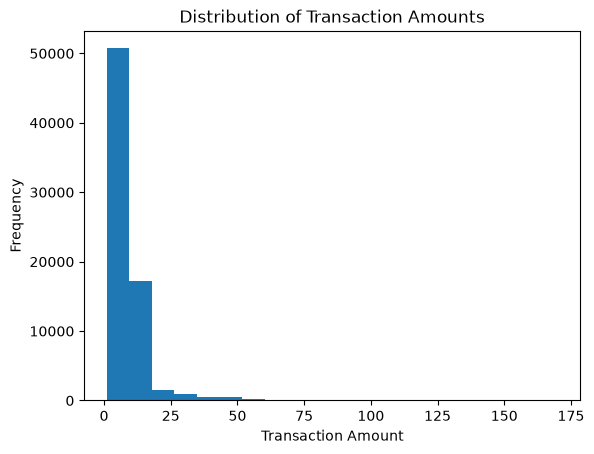

In [ ]:
### distribution of transactionAmt
plt.hist(df['transAmt'], bins=20)
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Amounts")
plt.show()

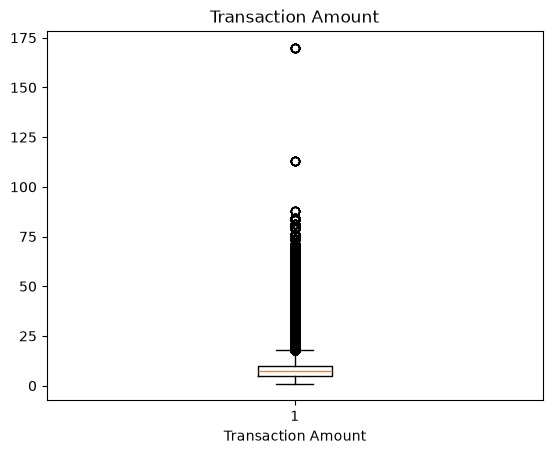

In [ ]:
### transAmt boxplot for outliers
plt.boxplot(df['transAmt'])
plt.title("Transaction Amount")
plt.show()

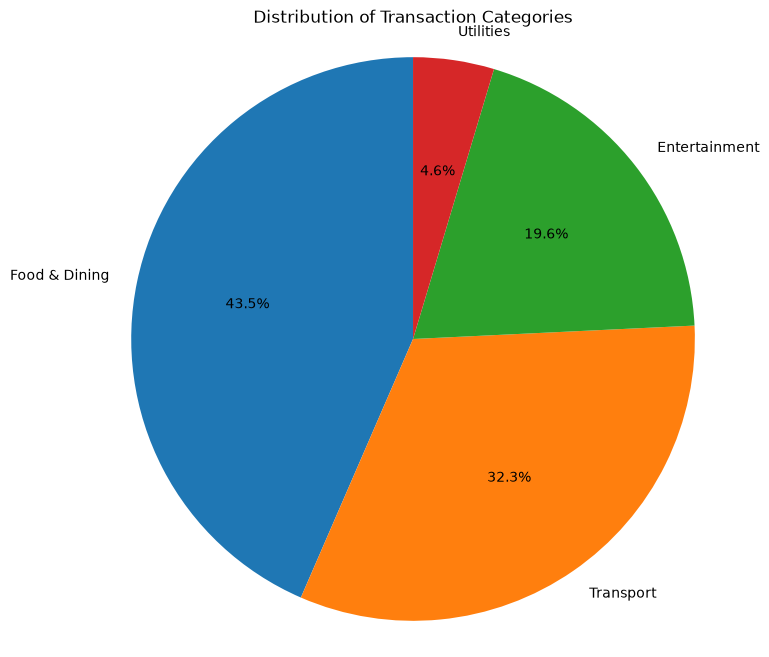

In [96]:
### Pie Chart Distribution of transaction category
category_counts = df['transCategoryName'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Transaction Categories')
plt.axis('equal')  # Makes the pie chart circular
plt.show()

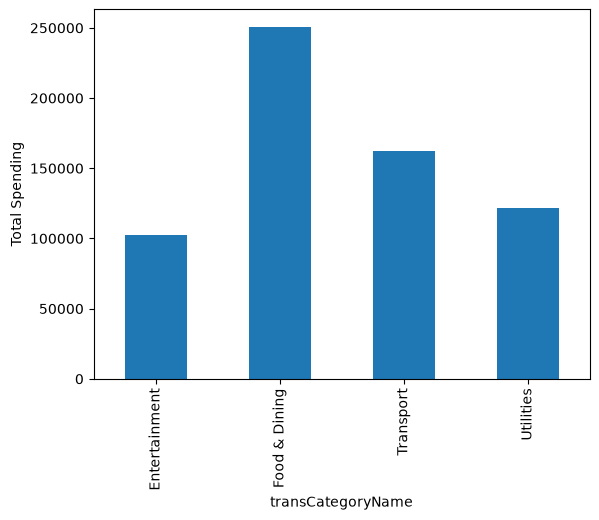

In [ ]:
### category spending
category_spending = df.groupby('transCategoryName')['transAmt'].sum()

category_spending.plot(kind='bar')
plt.ylabel("Total Spending")
plt.show()

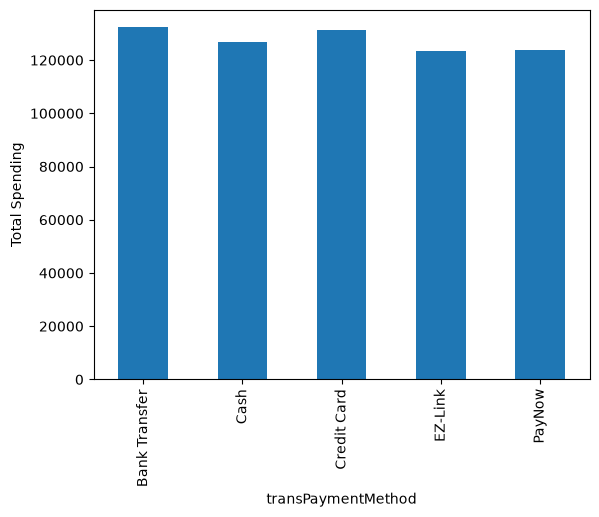

In [ ]:
### spending by payment method
payment = df.groupby('transPaymentMethod')['transAmt'].sum()

payment.plot(kind='bar')
plt.ylabel("Total Spending")
plt.show()

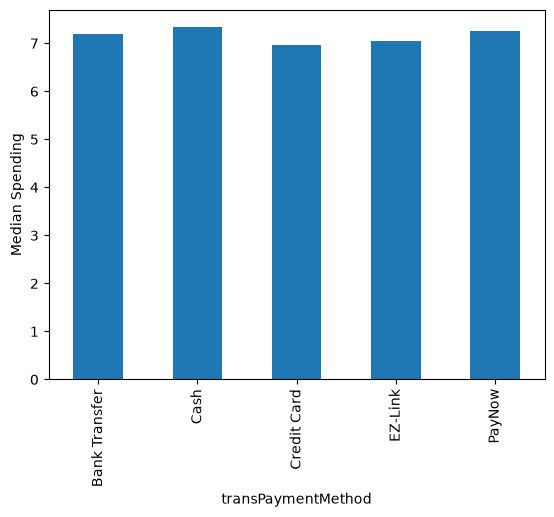

In [104]:
### spending by payment method
payment = df.groupby('transPaymentMethod')['transAmt'].median()

payment.plot(kind='bar')
plt.ylabel("Median Spending")
plt.show()

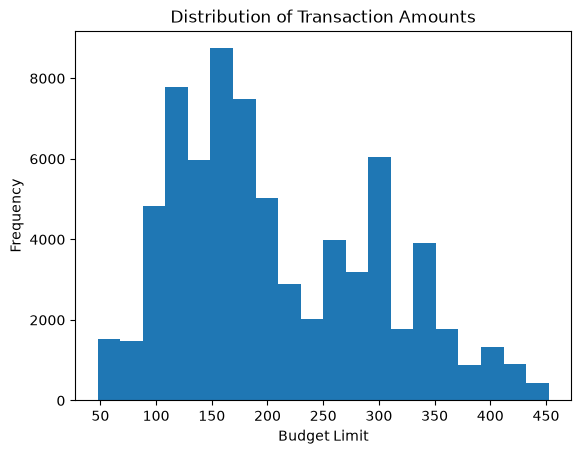

In [88]:
plt.hist(df['budgetLimit'], bins=20)
plt.xlabel("Budget Limit")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Amounts")
plt.show()

In [105]:
budget_analysis = df.groupby('budgetName').agg({
    'budgetLimit':'first',
    'transAmt':'sum'
})

budget_analysis['Remaining'] = budget_analysis['budgetLimit'] - budget_analysis['transAmt']

budget_analysis

,budgetLimit,transAmt,Remaining
budgetName,,,
Bills,50.00,1541.23,-1491.23
Entertainment Budget,100.90,102787.72,-102686.82
Food,200.00,10909.39,-10709.39
Food & Dining Budget,320.39,236058.77,-235738.38
Food Budget,400.00,3766.98,-3366.98
Transport,100.00,1918.74,-1818.74
Transport Budget,120.00,160576.50,-160456.50
Utilities Budget,100.00,119991.08,-119891.08


In [115]:
### Time - budget - transaction analysis
### How much is spending for every budget across the time - monthly, weekly, daily (budget and transaction)

monthly_spending = (
    df.groupby([
        'budgetName',
        pd.Grouper(key='transDate', freq='ME')
    ])
    .agg(
        budgetLimit=('budgetLimit', 'first'),
        totalSpent=('transAmt', 'sum')
    )
    .reset_index()
)

monthly_spending

,budgetName,transDate,budgetLimit,totalSpent
0,Bills,2025-07-31,50.00,92.54
1,Bills,2025-08-31,50.00,45.34
2,Bills,2025-09-30,50.00,93.42
3,Bills,2025-10-31,50.00,89.72
4,Bills,2025-11-30,50.00,54.43
...,...,...,...,...
99,Utilities Budget,2026-03-31,178.73,11732.46
100,Utilities Budget,2026-04-30,178.73,12503.33
101,Utilities Budget,2026-05-31,178.73,9546.46
102,Utilities Budget,2026-06-30,100.00,12101.62


In [116]:
weekly_spending = (
    df.groupby([
        'budgetName',
        pd.Grouper(key='transDate', freq='W')
    ])
    .agg(
        budgetLimit=('budgetLimit', 'first'),
        totalSpent=('transAmt', 'sum')
    )
    .reset_index()
)

weekly_spending

,budgetName,transDate,budgetLimit,totalSpent
0,Bills,2025-07-13,50.00,50.49
1,Bills,2025-07-27,50.00,42.05
2,Bills,2025-08-10,50.00,20.84
3,Bills,2025-08-31,50.00,24.50
4,Bills,2025-09-07,50.00,34.16
...,...,...,...,...
397,Utilities Budget,2026-06-14,100.00,2622.81
398,Utilities Budget,2026-06-21,178.73,2645.35
399,Utilities Budget,2026-06-28,254.40,3405.88
400,Utilities Budget,2026-07-05,178.73,2657.60


In [117]:
daily_spending = (
    df.groupby([
        'budgetName',
        pd.Grouper(key='transDate', freq='D')
    ])
    .agg(
        budgetLimit=('budgetLimit', 'first'),
        totalSpent=('transAmt', 'sum')
    )
    .reset_index()
)

daily_spending

,budgetName,transDate,budgetLimit,totalSpent
0,Bills,2025-07-10,50.00,50.49
1,Bills,2025-07-23,50.00,42.05
2,Bills,2025-08-09,50.00,20.84
3,Bills,2025-08-29,50.00,24.50
4,Bills,2025-09-02,50.00,34.16
...,...,...,...,...
2206,Utilities Budget,2026-07-03,254.40,273.30
2207,Utilities Budget,2026-07-04,178.73,754.24
2208,Utilities Budget,2026-07-07,269.06,932.80
2209,Utilities Budget,2026-07-08,178.73,599.72


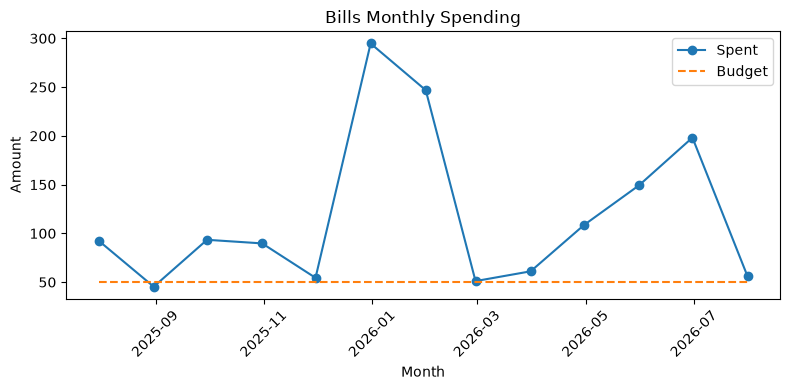

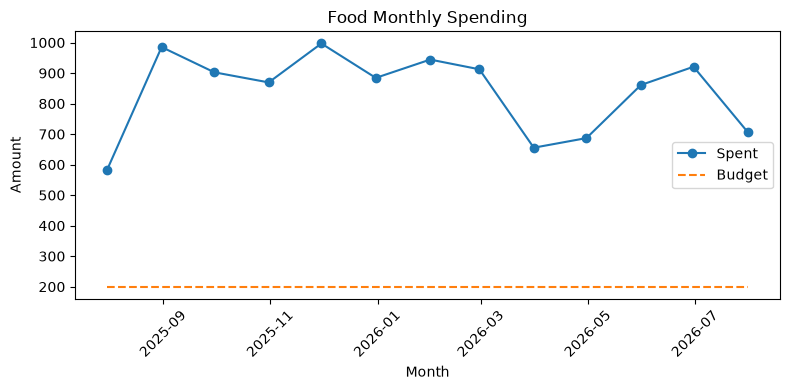

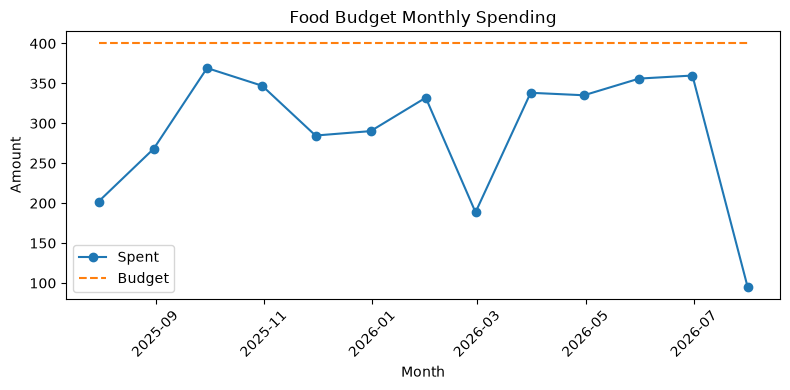

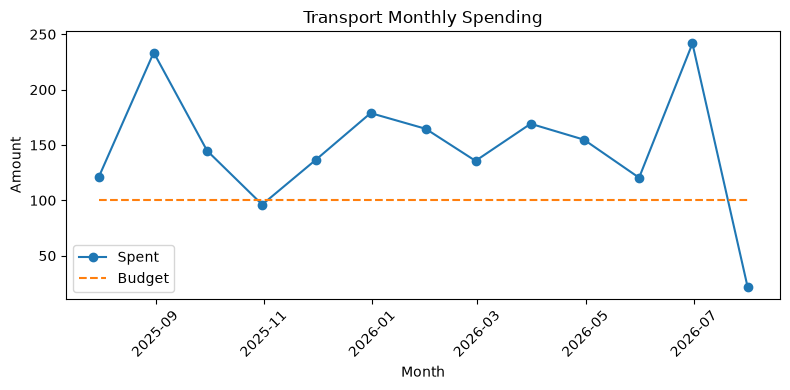

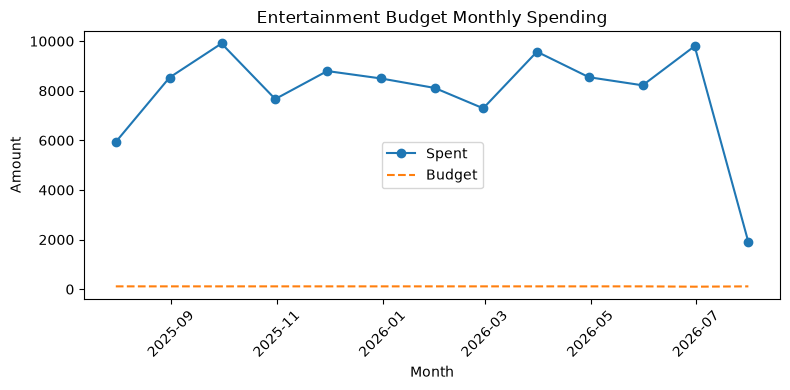

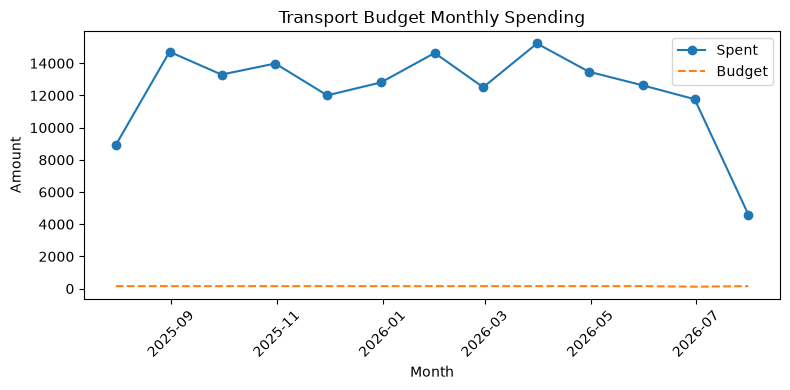

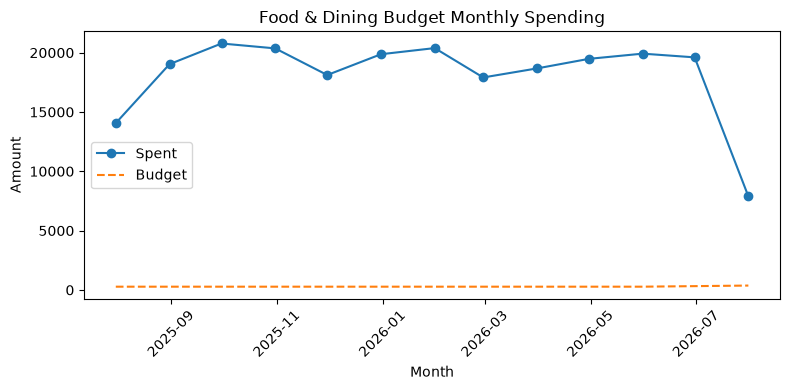

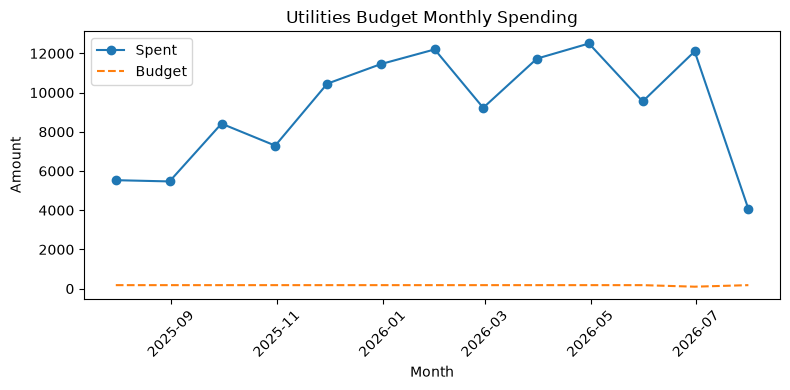

In [118]:
monthly_spending = monthly_spending.sort_values('transDate')

for budget in monthly_spending['budgetName'].unique():
    subset = monthly_spending[monthly_spending['budgetName'] == budget]

    plt.figure(figsize=(8,4))
    plt.plot(subset['transDate'], subset['totalSpent'], marker='o', label='Spent')
    plt.plot(subset['transDate'], subset['budgetLimit'], linestyle='--', label='Budget')

    plt.title(f'{budget} Monthly Spending')
    plt.xlabel('Month')
    plt.ylabel('Amount')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()